# EMA/SMA Fusion: Evaluating a Crypto Trend-Following Strategy
**Irene Undiandeye**

## Research question

The EMA/SMA Fusion strategy was developed for an algorithmic trading case study as a systematic way to trade Bitcoin (BTC), Ethereum (ETH) and Ripple (XRP). It combines short-term momentum from exponential moving averages (EMA) with a longer-term trend filter from a simple moving average (SMA). This notebook asks whether the strategy outperforms simply buying and holding the same three assets over 2020 to 2025, once realistic trading costs are included, and how robust the answer is to the choice of timeframe, parameters and period.

## Strategy rules

The strategy enters a position when the fast EMA (9 periods) is above the slow EMA (21 periods), the price is above the 50-period SMA, and the price is at least 0.5% above the slow EMA, a buffer intended to filter out false breakouts. It exits when the fast EMA falls below the slow EMA and the price falls below the SMA.

## Contents

1. Data
2. Backtest design
3. Main results on hourly data
4. The role of trading costs
5. Robustness: timeframe
6. Robustness: parameters
7. Robustness: sub-periods
8. Conclusions and recommendations

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import vectorbt as vbt

warnings.filterwarnings('ignore')
os.makedirs('images', exist_ok=True)
pd.set_option('display.float_format', '{:,.2f}'.format)
plt.rcParams['figure.dpi'] = 110

## 1. Data

Hourly closing prices for BTC, ETH and XRP against the US dollar stablecoin USDT come from the Binance public API (see `download_btc.ipynb`) and cover 31 December 2019 to 8 October 2025.

In [2]:
assets = ['BTC', 'ETH', 'XRP']
close = pd.concat({a: pd.read_csv(f'data/{a}USDT_1h_2025-10-08.csv', parse_dates=['timestamp'],
                                  index_col='timestamp')['close'] for a in assets}, axis=1)

print(f"Period: {close.index.min()} to {close.index.max()}")
print(f"Hourly observations: {len(close):,}")
print(f"Missing prices: {close.isna().sum().sum()}")
print(f"Gaps longer than one hour: {(close.index.to_series().diff() > pd.Timedelta('1h')).sum()}")
close.iloc[[0, -1]]

Period: 2019-12-31 23:00:00 to 2025-10-08 09:00:00
Hourly observations: 50,547
Missing prices: 0
Gaps longer than one hour: 15


,BTC,ETH,XRP
timestamp,,,
2019-12-31 23:00:00,"7,195.23",129.16,0.19
2025-10-08 09:00:00,"122,516.98","4,482.20",2.87


The three series are fully aligned, with no missing prices. Fifteen short gaps of a few hours, most likely exchange maintenance windows, are too small to affect the results.

## 2. Backtest design

Several choices are made to keep the backtest realistic and the comparison fair. Capital of 100,000 is split equally across the three assets, and each third is managed independently, so one asset's signals cannot consume the others' capital. Each position uses the whole of its asset's allocation. Signals are computed on a bar's closing price but executed at the close of the *following* bar, which avoids look-ahead bias, since in practice a signal can only be acted on after the bar has closed. A fee of 0.1% is charged on every trade, matching Binance's standard spot fee. The benchmark holds the same equal-weighted portfolio for the whole period without trading.

In [3]:
INIT_CASH = 100_000

def signals(close, fast=9, slow=21, sma=50, buffer=0.005):
    ema_fast = close.ewm(span=fast, adjust=False).mean()
    ema_slow = close.ewm(span=slow, adjust=False).mean()
    sma_line = close.rolling(sma).mean()
    entries = (ema_fast > ema_slow) & (close > sma_line) & (close > ema_slow * (1 + buffer))
    exits = (ema_fast < ema_slow) & (close < sma_line)
    return entries, exits

def backtest(close, freq, fees=0.001, group=True, **params):
    entries, exits = signals(close, **params)
    return vbt.Portfolio.from_signals(
        close, entries.shift(1, fill_value=False), exits.shift(1, fill_value=False),
        init_cash=INIT_CASH / close.shape[1], fees=fees, freq=freq, group_by=group or None)

def buy_and_hold(close, freq, group=True):
    return vbt.Portfolio.from_holding(close, init_cash=INIT_CASH / close.shape[1], freq=freq, group_by=group or None)

def summary(pf):
    return pd.Series({
        'Total return (%)': pf.total_return() * 100,
        'Annual return (%)': pf.annualized_return() * 100,
        'Sharpe ratio': pf.sharpe_ratio(),
        'Sortino ratio': pf.sortino_ratio(),
        'Max drawdown (%)': pf.max_drawdown() * 100,
        'Trades': pf.trades.count(),
    })

## 3. Main Results on Hourly Data

In [4]:
strategy_1h = backtest(close, '1h')
benchmark_1h = buy_and_hold(close, '1h')
pd.DataFrame({'EMA/SMA Fusion': summary(strategy_1h), 'Buy and hold': summary(benchmark_1h)})

,EMA/SMA Fusion,Buy and hold
Total return (%),417.57,"2,119.96"
Annual return (%),32.96,71.13
Sharpe ratio,0.85,1.10
Sortino ratio,1.20,1.51
Max drawdown (%),-73.11,-79.58
Trades,"2,428.00",3.00


In [5]:
per_asset = pd.DataFrame({
    'Strategy return (%)': backtest(close, '1h', group=False).total_return() * 100,
    'Buy and hold return (%)': buy_and_hold(close, '1h', group=False).total_return() * 100,
    'Strategy trades': backtest(close, '1h', group=False).trades.count(),
})
per_asset

,Strategy return (%),Buy and hold return (%),Strategy trades
BTC,186.37,"1,602.75",757
ETH,740.96,"3,370.27",815
XRP,325.37,"1,386.86",856


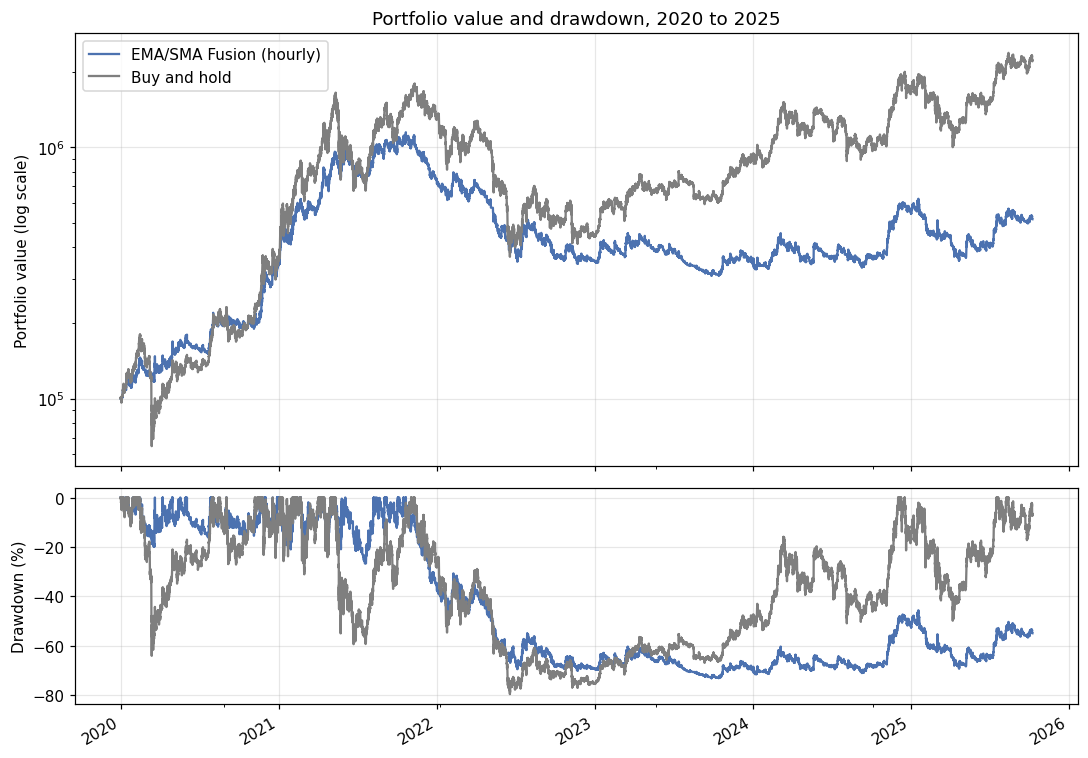

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
strategy_1h.value().plot(ax=axes[0], label='EMA/SMA Fusion (hourly)', color='#4c72b0')
benchmark_1h.value().plot(ax=axes[0], label='Buy and hold', color='#7f7f7f')
axes[0].set_yscale('log')
axes[0].set_ylabel('Portfolio value (log scale)')
axes[0].set_title('Portfolio value and drawdown, 2020 to 2025')
axes[0].legend()
axes[0].grid(alpha=0.3)
(strategy_1h.drawdown() * 100).plot(ax=axes[1], color='#4c72b0', label='EMA/SMA Fusion')
(benchmark_1h.drawdown() * 100).plot(ax=axes[1], color='#7f7f7f', label='Buy and hold')
axes[1].set_ylabel('Drawdown (%)')
axes[1].set_xlabel('')
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('images/equity_drawdown.png', bbox_inches='tight')
plt.show()

On hourly data, the strategy returns about 420% over the period against about 2,120% for buy-and-hold, with a lower Sharpe ratio. Its worst drawdown is somewhat smaller, but nowhere near enough to compensate for the lost return. The strategy underperforms buy-and-hold on every one of the three assets.

These results differ sharply from the figures reported in the original case study (a 5,216% return with a Sharpe ratio of 1.41). The original backtest contained a sizing error: vectorbt's `size_type='amount'` interprets the size as a number of coins rather than a cash amount, so each order attempted to buy tens of thousands of coins, and the reported fees exceeded the portfolio's starting capital many times over. It also executed trades at the same bar's closing price that generated the signal. The corrected design above removes both problems.

## 4. The Role of Trading Costs

The strategy trades about 2,400 times in under six years. The table below shows how its performance depends on the cost per trade.

In [7]:
fee_levels = [0.0, 0.0005, 0.001, 0.002]
fees_table = pd.DataFrame({f'{f * 100:.2f}%': summary(backtest(close, '1h', fees=f)) for f in fee_levels}).T
fees_table.index.name = 'Fee per trade'
fees_table

,Total return (%),Annual return (%),Sharpe ratio,Sortino ratio,Max drawdown (%),Trades
Fee per trade,,,,,,
0.00%,"2,550.09",76.46,1.45,2.08,-62.08,"2,428.00"
0.05%,"1,070.53",53.16,1.15,1.64,-65.98,"2,428.00"
0.10%,417.57,32.96,0.85,1.20,-73.11,"2,428.00"
0.20%,1.52,0.26,0.24,0.34,-88.43,"2,428.00"


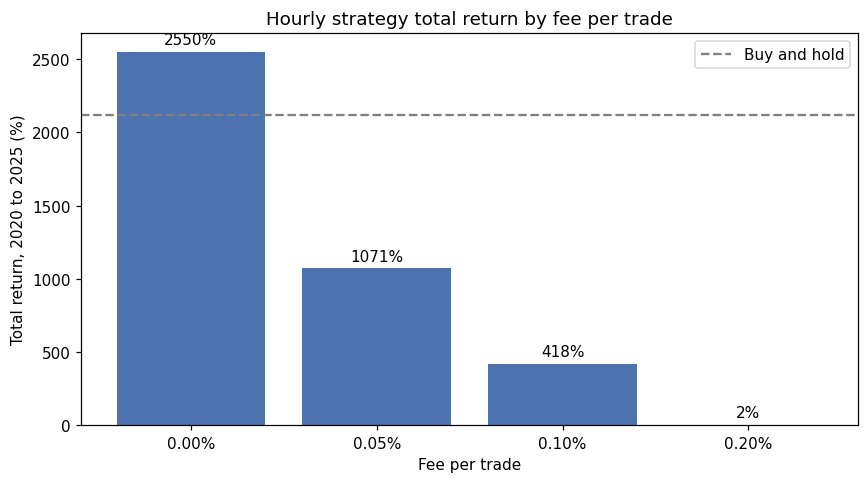

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(fees_table.index, fees_table['Total return (%)'], color='#4c72b0')
ax.axhline(summary(benchmark_1h)['Total return (%)'], color='#7f7f7f', ls='--', label='Buy and hold')
ax.bar_label(bars, fmt='%.0f%%', padding=3)
ax.set_title('Hourly strategy total return by fee per trade')
ax.set_xlabel('Fee per trade')
ax.set_ylabel('Total return, 2020 to 2025 (%)')
ax.legend()
plt.tight_layout()
plt.savefig('images/fee_sensitivity.png', bbox_inches='tight')
plt.show()

Without trading costs, the hourly strategy would have returned about 2,550% and beaten buy-and-hold with a Sharpe ratio of 1.45. At the standard 0.1% fee, costs consume most of that, and at 0.2% the strategy earns almost nothing over six years. The signals do contain some information about trends, but on hourly bars they generate far too many trades to be profitable after costs. This also suggests where the original headline figure came from: frictionless backtests of high-frequency strategies look far better than anything achievable in practice.

## 5. Robustness: Timeframe

If turnover is the problem, applying the same rules to slower bars should help. The strategy is repeated on 4-hour and daily closing prices.

In [9]:
timeframes = {}
for rule in ['1h', '4h', '1D']:
    prices = close if rule == '1h' else close.resample(rule).last()
    timeframes[f'Strategy ({rule})'] = summary(backtest(prices, rule))
timeframes['Buy and hold'] = summary(benchmark_1h)
timeframe_table = pd.DataFrame(timeframes).T
timeframe_table

,Total return (%),Annual return (%),Sharpe ratio,Sortino ratio,Max drawdown (%),Trades
Strategy (1h),417.57,32.96,0.85,1.20,-73.11,"2,428.00"
Strategy (4h),808.30,46.54,1.04,1.48,-61.53,675.00
Strategy (1D),912.06,49.27,1.08,1.58,-60.78,105.00
Buy and hold,"2,119.96",71.13,1.10,1.51,-79.58,3.00


On 4-hour and daily bars, the number of trades falls by a factor of about 4 to 23, and the strategy's Sharpe ratio rises to about 1.05 to 1.08, close to buy-and-hold's 1.10. Its maximum drawdown is also clearly smaller, about −61% against −80%. Total return remains far below buy-and-hold, because the strategy is out of the market for long periods, including parts of strong rallies.

On slower timeframes, then, the strategy behaves as a risk-reduction tool: it delivers roughly the same return per unit of risk as holding, with shallower losses, but not higher returns. Because the timeframe was chosen after seeing these results, this finding should be confirmed on new data before being relied on.

## 6. Robustness: Parameters

To check whether the results depend on the specific choice of 9 and 21 periods, the Sharpe ratio is computed for a grid of fast and slow EMA lengths on 4-hour bars, keeping the 50-period SMA and the 0.5% buffer.

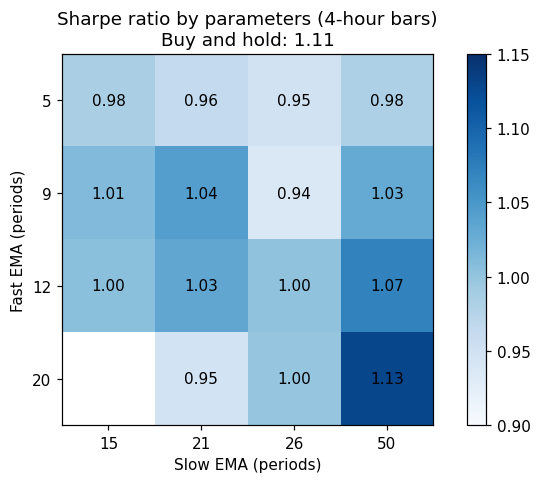

In [10]:
close_4h = close.resample('4h').last()
grid = {}
for fast in [5, 9, 12, 20]:
    for slow in [15, 21, 26, 50]:
        if slow > fast:
            grid[(fast, slow)] = backtest(close_4h, '4h', fast=fast, slow=slow).sharpe_ratio()
grid = pd.Series(grid).unstack()
grid.index.name, grid.columns.name = 'Fast EMA', 'Slow EMA'

fig, ax = plt.subplots(figsize=(6.5, 4.5))
im = ax.imshow(grid.values, cmap='Blues', vmin=0.9, vmax=1.15)
ax.set_xticks(range(len(grid.columns)), grid.columns)
ax.set_yticks(range(len(grid.index)), grid.index)
ax.set_xlabel('Slow EMA (periods)')
ax.set_ylabel('Fast EMA (periods)')
for i in range(grid.shape[0]):
    for j in range(grid.shape[1]):
        if not np.isnan(grid.values[i, j]):
            ax.text(j, i, f'{grid.values[i, j]:.2f}', ha='center', va='center')
ax.set_title(f'Sharpe ratio by parameters (4-hour bars)\nBuy and hold: {buy_and_hold(close_4h, "4h").sharpe_ratio():.2f}')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig('images/parameter_sensitivity.png', bbox_inches='tight')
plt.show()

The Sharpe ratio stays between about 0.94 and 1.13 across all combinations, so the conclusions do not hinge on one lucky parameter choice. Equally, no combination clearly beats buy-and-hold's Sharpe ratio. The parameters used by the live paper-trading bot (EMA 10 and 26 with a 0.2% buffer) give very similar results:

In [11]:
pd.DataFrame({
    'Live bot parameters, hourly': summary(backtest(close, '1h', fast=10, slow=26, buffer=0.002)),
    'Live bot parameters, 4-hour': summary(backtest(close_4h, '4h', fast=10, slow=26, buffer=0.002)),
})

,"Live bot parameters, hourly","Live bot parameters, 4-hour"
Total return (%),520.24,715.72
Annual return (%),37.20,43.83
Sharpe ratio,0.90,1.00
Sortino ratio,1.29,1.42
Max drawdown (%),-72.23,-60.82
Trades,"2,577.00",637.00


## 7. Robustness: Sub-periods

The 4-hour strategy is evaluated separately on the first and second halves of the sample.

In [12]:
periods = {}
for start, end in [('2020', '2022'), ('2023', '2025')]:
    prices = close_4h.loc[start:end]
    periods[f'Strategy {start}-{end}'] = summary(backtest(prices, '4h'))
    periods[f'Buy and hold {start}-{end}'] = summary(buy_and_hold(prices, '4h'))
pd.DataFrame(periods).T

,Total return (%),Annual return (%),Sharpe ratio,Sortino ratio,Max drawdown (%),Trades
Strategy 2020-2022,326.33,62.08,1.15,1.62,-61.22,341.00
Buy and hold 2020-2022,340.79,63.89,1.01,1.40,-79.34,3.00
Strategy 2023-2025,147.64,38.71,1.14,1.63,-41.71,332.00
Buy and hold 2023-2025,554.99,97.03,1.51,2.18,-44.15,3.00


The two periods tell different stories. From 2020 to 2022, a period that ended in a deep crypto bear market, the strategy matched buy-and-hold's return with a higher Sharpe ratio and a much smaller drawdown, which is exactly the protection a trend filter is meant to provide. From 2023 to 2025, a strong recovery, it captured well under a third of buy-and-hold's return. The strategy's value depends heavily on the market regime: it helps most when large declines occur and costs the most during sustained rallies.

## 8. Conclusions and Recommendations

The EMA/SMA Fusion strategy does not outperform buying and holding BTC, ETH and XRP over 2020 to 2025 once realistic trading costs are included. On hourly data it returns about 420% against 2,120% for buy-and-hold, because its roughly 2,400 trades turn a strategy that would be profitable without costs into one that lags badly. The headline results originally reported for the case study were driven by a position-sizing error and same-bar execution, and are not reproducible.

The strategy is not without merit. Its signals capture genuine trend information, and on 4-hour or daily bars it achieves a risk-adjusted return close to buy-and-hold's while reducing the maximum drawdown from about −80% to about −61%. These results are stable across a wide range of parameters, and the strategy protected capital well during the 2022 bear market.

The following recommendations follow from this evaluation. The strategy should not be run on hourly bars; trading on 4-hour or daily bars cuts costs dramatically with no loss of risk-adjusted performance. It is best treated as a risk-management overlay for investors who want crypto exposure with shallower drawdowns, not as a way to beat the market. Before any real deployment, the timeframe and parameters should be validated through walk-forward testing on data not used to choose them, slippage should be modelled alongside fees, and the live bot should use exactly the parameters that were backtested. Further improvements worth testing include volatility-based position sizing, which the original proposal described but never implemented, and a wider universe of assets.

## Note on live paper trading

The strategy was deployed as an automated paper-trading bot on Alpaca, which traded from mid-2025 until March 2026. The bot used slightly different parameters (EMA 10 and 26 with a 0.2% buffer), and complete trade logs from that period are not included in this repository, so its live performance is not evaluated here.